In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1947_bacteria_4876.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4875.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1954_bacteria_4886.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1951_bacteria_4882.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4874.jpeg
/kaggle/input/datasets/paultimothymooney

In [5]:
import os

# See exactly what Kaggle named your input folder
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    if root.count(os.sep) - "/kaggle/input".count(os.sep) > 2:
        break

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/paultimothymooney
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia


In [6]:
BASE_DIR = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

for split in ["train", "val", "test"]:
    split_path = os.path.join(BASE_DIR, split)
    print(f"\n📁 {split.upper()}")
    for cls in ["NORMAL", "PNEUMONIA"]:
        cls_path = os.path.join(split_path, cls)
        n = len(os.listdir(cls_path))
        print(f"   {cls}: {n} images")


📁 TRAIN
   NORMAL: 1341 images
   PNEUMONIA: 3875 images

📁 VAL
   NORMAL: 8 images
   PNEUMONIA: 8 images

📁 TEST
   NORMAL: 234 images
   PNEUMONIA: 390 images


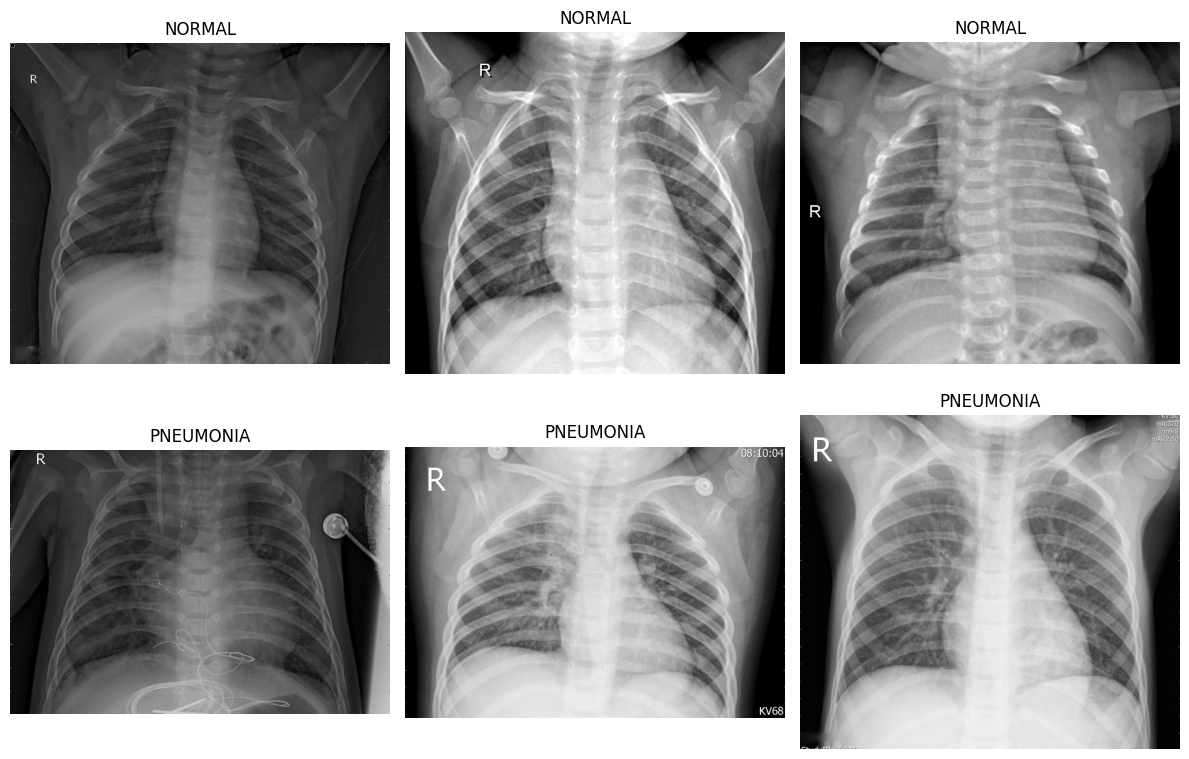

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Show 3 NORMAL and 3 PNEUMONIA sample images side by side
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

normal_dir = os.path.join(BASE_DIR, "train", "NORMAL")
pneumonia_dir = os.path.join(BASE_DIR, "train", "PNEUMONIA")

normal_samples = os.listdir(normal_dir)[:3]
pneumonia_samples = os.listdir(pneumonia_dir)[:3]

for i, fname in enumerate(normal_samples):
    img = mpimg.imread(os.path.join(normal_dir, fname))
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title("NORMAL")
    axes[0, i].axis("off")

for i, fname in enumerate(pneumonia_samples):
    img = mpimg.imread(os.path.join(pneumonia_dir, fname))
    axes[1, i].imshow(img, cmap="gray")
    axes[1, i].set_title("PNEUMONIA")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [8]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)   # MobileNetV2's expected input size
BATCH_SIZE = 32

BASE_DIR = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"


# ---- TRAINING generator: with heavy augmentation + carved-out validation split ----
train_datagen = ImageDataGenerator(
    rescale=1./255,              # pixel values 0-255 -> 0-1 (easier for the model to digest)
    rotation_range=10,           # tilt the image slightly
    width_shift_range=0.1,       # nudge left/right
    height_shift_range=0.1,      # nudge up/down
    zoom_range=0.15,             # zoom in/out a bit
    brightness_range=[0.8, 1.2], # simulate different X-ray machine exposures
    horizontal_flip=False,       # DO NOT flip chest X-rays! Left/right lung anatomy matters medically
    validation_split=0.1         # carve out 10% of TRAIN folder as our own validation set
)

# ---- TEST generator: NO augmentation, only rescaling (we evaluate on real, untouched images) ----
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 4695 images belonging to 2 classes.
Found 521 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [9]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# ---- Load MobileNetV2's "body" (the trick-knowing part), without its original head ----
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,        # we don't want its original 1000-class ImageNet head
    weights="imagenet"        # load the pre-trained knowledge
)

# ---- Freeze the base for now: don't let training mess up what it already knows (yet) ----
base_model.trainable = False

# ---- Build our own small "head" on top, specialized for Normal vs Pneumonia ----
x = base_model.output
x = GlobalAveragePooling2D()(x)      # squashes each feature map into a single number
x = BatchNormalization()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)                  # randomly "mutes" 40% of neurons each step -> prevents memorizing
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)   # 1 number between 0-1: probability of Pneumonia

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", "AUC", "Precision", "Recall"]
)

model.summary()

I0000 00:00:1791004848.936020      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791004848.939662      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,435,393 (9.29 MB)

 Trainable params: 174,849 (683.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [10]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ---- Step A: Calculate class weights automatically from the real counts ----
labels = train_generator.classes  # the true label of every image in the train generator
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)
class_weights = {i: w for i, w in enumerate(class_weights_array)}
print("Class weights:", class_weights)
# Expect something like {0: 1.75, 1: 0.61} -> NORMAL (0) gets ~3x more "attention weight" than PNEUMONIA (1)

# ---- Step B: Callbacks = automatic "coaches" watching the training ----
callbacks = [
    EarlyStopping(
        monitor="val_recall",     # we care MOST about not missing real pneumonia cases
        mode="max",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7
    ),
    ModelCheckpoint(
        "best_model_stage1.keras",
        monitor="val_recall",
        mode="max",
        save_best_only=True
    )
]

# ---- Step C: Train! (Stage 1 - base frozen, only training our new head) ----
history_stage1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Class weights: {0: np.float64(1.9449047224523612), 1: np.float64(0.6730217889908257)}
Epoch 1/15


2026-10-03 05:22:23.137384: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 05:22:23.292177: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 05:22:23.429192: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1791004946.435412     154 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


118/147 ━━━━━━━━━━━━━━━━━━━━ 25s 874ms/step - AUC: 0.7020 - Precision: 0.9279 - Recall: 0.2796 - accuracy: 0.4509 - loss: 0.8860

2026-10-03 05:24:18.812295: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 05:24:18.948753: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 940ms/step - AUC: 0.7254 - Precision: 0.9339 - Recall: 0.3216 - accuracy: 0.4818 - loss: 0.8343

2026-10-03 05:25:12.406955: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 05:25:12.543536: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_recall` which is not available. Available metrics are: AUC,Precision,Recall,accuracy,loss,val_AUC,val_Precision,val_Recall,val_accuracy,val_loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_recall available.
  if self._should_save_model(epoch, batch, logs, filepath

147/147 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - AUC: 0.8311 - Precision: 0.9588 - Recall: 0.5204 - accuracy: 0.6271 - loss: 0.5983 - val_AUC: 0.9643 - val_Precision: 0.9612 - val_Recall: 0.8966 - val_accuracy: 0.8964 - val_loss: 0.3009 - learning_rate: 1.0000e-04
Epoch 2/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 98s 668ms/step - AUC: 0.9510 - Precision: 0.9708 - Recall: 0.8283 - accuracy: 0.8539 - loss: 0.2921 - val_AUC: 0.9770 - val_Precision: 0.9773 - val_Recall: 0.8915 - val_accuracy: 0.9040 - val_loss: 0.2202 - learning_rate: 1.0000e-04
Epoch 3/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 99s 676ms/step - AUC: 0.9665 - Precision: 0.9742 - Recall: 0.8784 - accuracy: 0.8924 - loss: 0.2332 - val_AUC: 0.9787 - val_Precision: 0.9913 - val_Recall: 0.8863 - val_accuracy: 0.9098 - val_loss: 0.2150 - learning_rate: 1.0000e-04
Epoch 4/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 100s 683ms/step - AUC: 0.9740 - Precision: 0.9781 - Recall: 0.8979 - accuracy: 0.9093 - loss: 0.2030 - val_AUC: 0.9829 - val_Precision: 0.9942 - val_Recal

In [11]:
model.save("stage1_final.keras")
print("Stage 1 model saved!")

Stage 1 model saved!


In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# ---- Step A: Unfreeze the base model, but only the LAST ~30 layers ----
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30   # keep everything before this frozen

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True


# ---- Step B: Re-compile with a MUCH smaller learning rate ----
# This is critical! A big learning rate here would wreck the pre-trained knowledge.
model.compile(
    optimizer = Adam(learning_rate = 1e-5),     # 10x smaller than Stage 1's 1e-4
    loss = "binary_crossentropy",
    metrics = ["accuracy", "AUC", "Precision", "Recall"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,435,393 (9.29 MB)

 Trainable params: 1,701,249 (6.49 MB)

 Non-trainable params: 734,144 (2.80 MB)

In [14]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np

labels = train_generator.classes
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)
class_weights = {i: w for i, w in enumerate(class_weights_array)}

# Corrected callbacks - capital "Recall" to match Keras's actual metric name
callbacks_stage2 = [
    EarlyStopping(
        monitor="val_Recall",
        mode="max",
        patience=5,
        restore_best_weights=True   # <- safety net: always end with the BEST epoch's weights
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7
    ),
    ModelCheckpoint(
        "best_model_stage2.keras",
        monitor="val_Recall",
        mode="max",
        save_best_only=True
    )
]

history_stage2 = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs = 10,            # fewer epochs needed - we're fine-tuning, not starting fresh
    class_weight = class_weights,
    callbacks = callbacks_stage2
)

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 135s 792ms/step - AUC: 0.9647 - Precision: 0.9498 - Recall: 0.9220 - accuracy: 0.9059 - loss: 0.2550 - val_AUC: 0.9628 - val_Precision: 0.8886 - val_Recall: 0.9897 - val_accuracy: 0.9002 - val_loss: 0.3028 - learning_rate: 1.0000e-05
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 99s 673ms/step - AUC: 0.9770 - Precision: 0.9783 - Recall: 0.9174 - accuracy: 0.9235 - loss: 0.1931 - val_AUC: 0.9494 - val_Precision: 0.8810 - val_Recall: 0.9948 - val_accuracy: 0.8964 - val_loss: 0.3918 - learning_rate: 1.0000e-05
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 97s 662ms/step - AUC: 0.9820 - Precision: 0.9788 - Recall: 0.9257 - accuracy: 0.9299 - loss: 0.1656 - val_AUC: 0.9404 - val_Precision: 0.8730 - val_Recall: 0.9948 - val_accuracy: 0.8887 - val_loss: 0.3805 - learning_rate: 1.0000e-05
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 97s 661ms/step - AUC: 0.9848 - Precision: 0.9842 - Recall: 0.9315 - accuracy: 0.9380 - loss: 0.1527 - val_AUC: 0.9604 - val_Precision: 0.900

In [15]:
model.save("stage2_final.keras")
print("Stage 2 (fine-tuned) model saved!")

Stage 2 (fine-tuned) model saved!


19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step

2026-10-03 06:04:14.747866: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 06:04:14.884624: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step 
CLASSIFICATION REPORT
              precision    recall  f1-score   support

      NORMAL     1.0000    0.4786    0.6474       234
   PNEUMONIA     0.7617    1.0000    0.8647       390

    accuracy                         0.8045       624
   macro avg     0.8809    0.7393    0.7561       624
weighted avg     0.8511    0.8045    0.7832       624



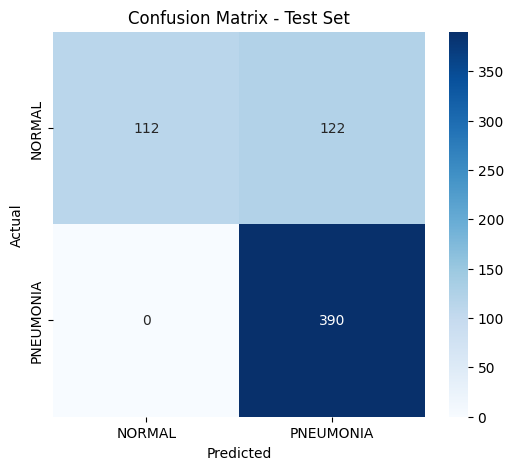

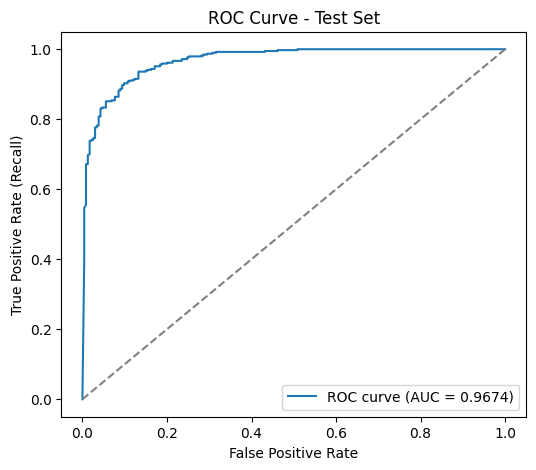


⚠️  False Negatives (missed real Pneumonia cases): 0
   False Positives (false alarms): 122
   True Positives (correctly caught Pneumonia): 390
   True Negatives (correctly identified Normal): 112


In [16]:
import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Step A: Get real predictions on the test set ----
test_generator.reset()  # make sure we start reading from image 0
y_true = test_generator.classes                     # the real answers
y_pred_probs = model.predict(test_generator, verbose=1).ravel()  # model's probability outputs (0-1)
y_pred = (y_pred_probs >= 0.5).astype(int)           # convert probability -> 0/1 decision at 0.5 threshold

class_names = list(test_generator.class_indices.keys())  # ['NORMAL', 'PNEUMONIA']

# ---- Step B: Classification Report (Precision, Recall, F1 per class) ----
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# ---- Step C: Confusion Matrix ----
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.show()

# ---- Step D: ROC Curve + AUC ----
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.show()

# ---- Step E: Explicitly call out the dangerous mistake type ----
tn, fp, fn, tp = cm.ravel()
print(f"\n⚠️  False Negatives (missed real Pneumonia cases): {fn}")
print(f"   False Positives (false alarms): {fp}")
print(f"   True Positives (correctly caught Pneumonia): {tp}")
print(f"   True Negatives (correctly identified Normal): {tn}")

In [17]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_true, y_pred_probs)

# Find thresholds where recall stays high (>=0.97) but precision improves
import pandas as pd
df = pd.DataFrame({"threshold": thresholds, 
                    "precision": precisions[:-1], 
                    "recall": recalls[:-1]})
candidates = df[df["recall"] >= 0.97].sort_values("precision", ascending=False)
print(candidates.head(10))

     threshold  precision    recall
187   0.986890   0.873272  0.971795
186   0.986872   0.871264  0.971795
183   0.985224   0.867882  0.976923
184   0.985811   0.867580  0.974359
185   0.986398   0.867277  0.971795
181   0.979644   0.866213  0.979487
182   0.981033   0.865909  0.976923
180   0.979581   0.864253  0.979487
179   0.979482   0.862302  0.979487
178   0.979182   0.860360  0.979487


CLASSIFICATION REPORT (Tuned Threshold = 0.9928)
              precision    recall  f1-score   support

      NORMAL     0.9246    0.7863    0.8499       234
   PNEUMONIA     0.8824    0.9615    0.9202       390

    accuracy                         0.8958       624
   macro avg     0.9035    0.8739    0.8851       624
weighted avg     0.8982    0.8958    0.8939       624



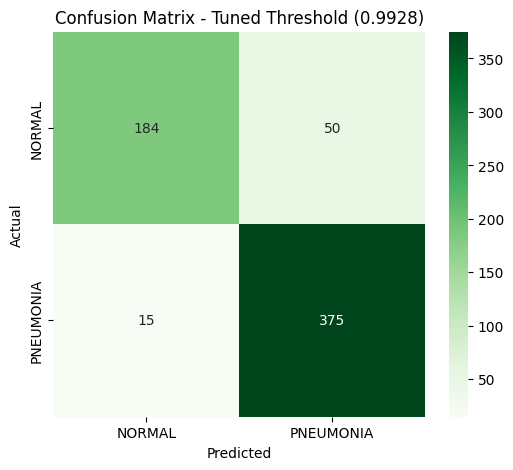


⚠️  False Negatives (missed real Pneumonia): 15
   False Positives (false alarms): 50
   True Positives: 375
   True Negatives: 184


In [18]:
BEST_THRESHOLD = 0.9928

y_pred_tuned = (y_pred_probs >= BEST_THRESHOLD).astype(int)

print("=" * 60)
print(f"CLASSIFICATION REPORT (Tuned Threshold = {BEST_THRESHOLD})")
print("=" * 60)
print(classification_report(y_true, y_pred_tuned, target_names=class_names, digits=4))

cm_tuned = confusion_matrix(y_true, y_pred_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - Tuned Threshold ({BEST_THRESHOLD})")
plt.show()

tn, fp, fn, tp = cm_tuned.ravel()
print(f"\n⚠️  False Negatives (missed real Pneumonia): {fn}")
print(f"   False Positives (false alarms): {fp}")
print(f"   True Positives: {tp}")
print(f"   True Negatives: {tn}")

In [19]:
import json

config = {
    "decision_threshold": 0.9928,
    "class_indices": {"NORMAL": 0, "PNEUMONIA": 1},
    "img_size": [224, 224],
    "notes": "Threshold tuned to balance recall vs false-alarm rate on held-out test set."
}

with open("model_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Config saved:", config)

Config saved: {'decision_threshold': 0.9928, 'class_indices': {'NORMAL': 0, 'PNEUMONIA': 1}, 'img_size': [224, 224], 'notes': 'Threshold tuned to balance recall vs false-alarm rate on held-out test set.'}


In [20]:
import tensorflow as tf

# Reload our fine-tuned model from disk
model = tf.keras.models.load_model("stage2_final.keras")
print("Model reloaded successfully!")
model.summary()

Model reloaded successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 5,837,893 (22.27 MB)

 Trainable params: 1,701,249 (6.49 MB)

 Non-trainable params: 734,144 (2.80 MB)

 Optimizer params: 3,402,500 (12.98 MB)

In [32]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow.keras.preprocessing import image as keras_image

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    img_array: preprocessed image, shape (1, 224, 224, 3)
    last_conv_layer_name: name of the last convolutional layer (our 'eyes' location)
    """
    # Build a model that maps the input image to:
    # (1) the activations of the last conv layer
    # (2) the final prediction output
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = 0  # binary sigmoid: single output neuron
        class_channel = preds[:, pred_index]

    # Gradient of the predicted class w.r.t. the last conv layer's output
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Average the gradients spatially -> importance weight per channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU + normalize to 0-1
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img = keras_image.load_img(img_path, target_size=(224, 224))
    img = keras_image.img_to_array(img)

    heatmap_resized = np.uint8(255 * heatmap)
    #jet = cm.get_cmap("jet")
    jet = plt.colormaps["jet"] 
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_resized]
    jet_heatmap = keras_image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras_image.img_to_array(jet_heatmap)

    overlayed = jet_heatmap * alpha + img
    overlayed = keras_image.array_to_img(overlayed)
    return overlayed


# ---- Find the name of MobileNetV2's last conv layer ----
last_conv_layer_name = "Conv_1"  # MobileNetV2's final conv block before pooling

print("Last conv layer:", last_conv_layer_name)
print([l.name for l in model.layers if "conv" in l.name.lower()][-5:])  # sanity check, shows last few conv-ish layers

Last conv layer: Conv_1
['expanded_conv_depthwise_relu', 'expanded_conv_project', 'expanded_conv_project_BN', 'Conv_1', 'Conv_1_bn']


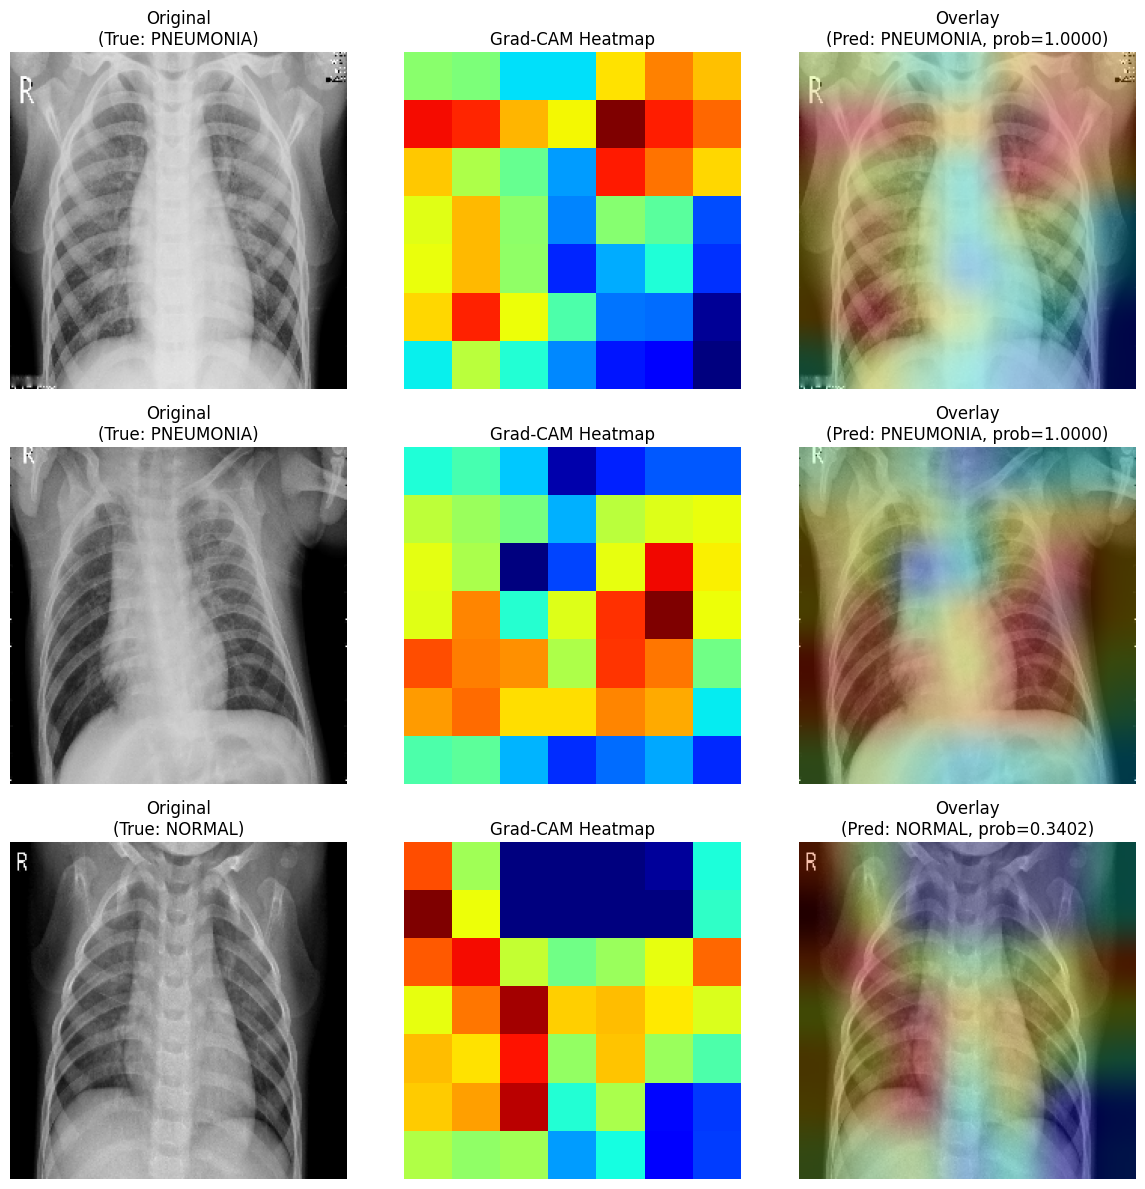

In [33]:
import os
import numpy as np

def preprocess_single_image(img_path):
    img = keras_image.load_img(img_path, target_size=(224, 224))
    array = keras_image.img_to_array(img)
    array = np.expand_dims(array, axis = 0)
    array = array/255.0  # same rescale as training   
    return array

# ---- Pick a few real test images: 2 correctly predicted PNEUMONIA, 1 correctly predicted NORMAL ----
pneumonia_dir = os.path.join(BASE_DIR, "test", "PNEUMONIA")
normal_dir = os.path.join(BASE_DIR, "test", "NORMAL")

sample_paths = [
    os.path.join(pneumonia_dir, os.listdir(pneumonia_dir)[0]),
    os.path.join(pneumonia_dir, os.listdir(pneumonia_dir)[1]),
    os.path.join(normal_dir, os.listdir(normal_dir)[0]),
]

fig, axes = plt.subplots(len(sample_paths), 3, figsize=(12, 4 * len(sample_paths)))

for i, img_path in enumerate(sample_paths):
    img_array = preprocess_single_image(img_path)

    # Model's prediction
    prob = model.predict(img_array, verbose=0)[0][0]
    predicted_label = "PNEUMONIA" if prob >= BEST_THRESHOLD else "NORMAL"

    # Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    overlayed = overlay_gradcam(img_path, heatmap)

    # Original image
    orig_img = keras_image.load_img(img_path, target_size=(224, 224))
    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title(f"Original\n(True: {'PNEUMONIA' if 'PNEUMONIA' in img_path else 'NORMAL'})")
    axes[i, 0].axis("off")

    # Heatmap alone
    axes[i, 1].imshow(heatmap, cmap="jet")
    axes[i, 1].set_title("Grad-CAM Heatmap")
    axes[i, 1].axis("off")

    # Overlay
    axes[i, 2].imshow(overlayed)
    axes[i, 2].set_title(f"Overlay\n(Pred: {predicted_label}, prob={prob:.4f})")
    axes[i, 2].axis("off")  

plt.tight_layout()
plt.show()